# 8. Comparación estadística de los modelos

Sección 9.10.4.6 del enunciado. Todas las pruebas usan las puntuaciones continuas guardadas en
los capítulos 6 y 7 para las **mismas 269.612 observaciones de prueba**, emparejadas por `id`.

* **DeLong** (obligatoria): ¿son iguales dos AUC calculados sobre las mismas observaciones?
  Implementación rápida de Sun y Xu (2014), $O(n \log n)$, en `src/estadistica.py`.
* **McNemar**: ¿cometen dos clasificadores errores con la misma frecuencia en el umbral de
  decisión elegido con entrenamiento?
* **Bootstrap pareado** (B = 2.000, semilla 42): intervalos percentiles de ΔAUC, ΔAUC-PR y ΔF1.

**Margen de relevancia práctica, fijado antes de ver los resultados: |ΔAUC| ≥ 0,005.** Con
269.612 observaciones el error estándar de una diferencia entre AUC correlacionados es del orden
de 0,001, así que diferencias que no cambian ninguna decisión de crédito pueden resultar
significativas. Un cambio de 0,005 en el AUC equivale a 0,01 en el coeficiente de Gini
($G = 2\,AUC - 1$), la unidad con la que se suelen comparar los modelos de riesgo de crédito;
por debajo de ese valor dos modelos se consideran equivalentes en la práctica. Para AUC-PR y F1
se usa el mismo margen. La escala de magnitud del curso (sección 9.9.1: < 0,01 trivial,
0,01-0,03 pequeña, 0,03-0,05 moderada, > 0,05 importante) se reporta como referencia adicional.

In [1]:
import itertools
import subprocess
import sys
import warnings

sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import roc_auc_score

import estadistica as est
import modelado as mo
import utils as u

u.estilo()
pd.set_option("display.max_columns", 30, "display.width", 200, "display.max_rows", 100)
MARGEN = 0.005
ALFA = 0.05
B = 2000

sk = mo.leer_puntuaciones("sklearn")
sp = mo.leer_puntuaciones("spark")
p = sk.merge(sp, on=["id", "default"], suffixes=("_sk", "_sp"), validate="one_to_one")
assert len(p) == len(sk) == len(sp) and p.notna().all().all(), "las observaciones no coinciden"
print(f"Observaciones emparejadas: {len(p):,} (sklearn {len(sk):,}, Spark {len(sp):,}); "
      f"defaults: {p['default'].sum():,}")
y = p["default"].to_numpy()
S = {("sklearn", m): p[f"{m}_sk"].to_numpy() for m in mo.ORDEN}
S.update({("spark", m): p[f"{m}_sp"].to_numpy() for m in mo.ORDEN})
umbral = {(e, m): mo.cargar_resultado(e, m)["umbral_youden"] for e in ("sklearn", "spark") for m in mo.ORDEN}


def magnitud(d):
    d = abs(d)
    return "trivial" if d < 0.01 else "pequeña" if d < 0.03 else "moderada" if d < 0.05 else "importante"

Observaciones emparejadas: 269,612 (sklearn 269,612, Spark 269,612); defaults: 53,864


## 8.1 Validación de la implementación de DeLong

Antes de usarla, la versión rápida se contrasta con (a) la versión directa $O(mn)$ de DeLong et
al. (1988), que evalúa explícitamente todos los pares positivo-negativo, y (b) la función
`roc.test(..., method = "delong", paired = TRUE)` del paquete **pROC** de R. Se usa una muestra
aleatoria de 3.000 observaciones del conjunto de prueba y tres pares de modelos con distintos
grados de empates (el árbol y Naive Bayes producen muchas puntuaciones repetidas).

In [2]:
rng = np.random.default_rng(u.SEMILLA)
idx = rng.choice(len(y), 3000, replace=False)
pares_val = [(("sklearn", "LogisticRegression"), ("sklearn", "GradientBoosting")),
             (("sklearn", "DecisionTree"), ("sklearn", "NaiveBayes")),
             (("sklearn", "RandomForest"), ("spark", "RandomForest"))]
filas = []
for a, b in pares_val:
    ys, s1, s2 = y[idx], S[a][idx], S[b][idx]
    rap = est.delong_prueba(ys, s1, s2)
    auc_d, cov_d = est.delong_directo(ys, s1, s2)
    z_d = (auc_d[0] - auc_d[1]) / np.sqrt(cov_d[0, 0] + cov_d[1, 1] - 2 * cov_d[0, 1])
    pd.DataFrame({"y": ys, "s1": s1, "s2": s2}).to_csv(u.RESULTADOS / "_delong_val.csv", index=False)
    r = subprocess.run(["Rscript", "-e", (
        'suppressMessages(library(pROC)); d <- read.csv("' + str(u.RESULTADOS / "_delong_val.csv") + '");'
        'r1 <- roc(d$y, d$s1, levels=c(0,1), direction="<", quiet=TRUE);'
        'r2 <- roc(d$y, d$s2, levels=c(0,1), direction="<", quiet=TRUE);'
        't <- roc.test(r1, r2, method="delong", paired=TRUE);'
        'cat(sprintf("%.12f %.12f %.12f %.12g", auc(r1), auc(r2), t$statistic, t$p.value))')],
        capture_output=True, text=True)
    a1_r, a2_r, z_r, p_r = map(float, r.stdout.split())
    filas.append({"par": f"{a[1]}({a[0]}) vs {b[1]}({b[0]})",
                  "AUC1 rápida": rap["auc1"], "AUC1 directa": auc_d[0], "AUC1 pROC": a1_r,
                  "z rápida": rap["z"], "z directa": z_d, "z pROC": z_r,
                  "p rápida": rap["p"], "p pROC": p_r})
(u.RESULTADOS / "_delong_val.csv").unlink()
val = pd.DataFrame(filas).set_index("par")
print("Máxima diferencia |z rápida - z directa|:", f"{(val['z rápida'] - val['z directa']).abs().max():.2e}")
print("Máxima diferencia |z rápida - z pROC|:   ", f"{(val['z rápida'] - val['z pROC']).abs().max():.2e}")
val

Máxima diferencia |z rápida - z directa|: 2.93e-14
Máxima diferencia |z rápida - z pROC|:    4.14e-13


,AUC1 rápida,AUC1 directa,AUC1 pROC,z rápida,z directa,z pROC,p rápida,p pROC
par,,,,,,,,
LogisticRegression(sklearn) vs GradientBoosting(sklearn),0.721098,0.721098,0.721098,-2.462299,-2.462299,-2.462299,1.380497e-02,1.380497e-02
DecisionTree(sklearn) vs NaiveBayes(sklearn),0.716540,0.716540,0.716540,4.960743,4.960743,4.960743,7.022413e-07,7.022413e-07
RandomForest(sklearn) vs RandomForest(spark),0.725607,0.725607,0.725607,0.926049,0.926049,0.926049,3.544206e-01,3.544206e-01


Las tres implementaciones coinciden hasta la precisión numérica en los AUC, en el estadístico z
(diferencia máxima de 3 × 10⁻¹⁴ con la versión directa y de 4 × 10⁻¹³ con pROC) y en el valor p,
también cuando hay muchos empates. Con las 269.612 observaciones, la versión directa necesitaría
evaluar 53.864 × 215.748 ≈ 1,16 × 10¹⁰ pares por modelo; la rápida tarda:

In [3]:
import time

t0 = time.time()
est.delong_prueba(y, S[("sklearn", "GradientBoosting")], S[("sklearn", "RandomForest")])
print(f"Prueba de DeLong con las 269.612 observaciones: {time.time() - t0:.2f} s")

Prueba de DeLong con las 269.612 observaciones: 0.08 s


## 8.2 AUC de cada modelo con su IC del 95 % (DeLong)

In [4]:
auc_tab = pd.DataFrame([{**{"entorno": e, "modelo": m}, **est.delong_auc(y, S[(e, m)])}
                        for e in ("sklearn", "spark") for m in mo.ORDEN])
auc_tab.pivot(index="modelo", columns="entorno", values=["auc", "ic_inf", "ic_sup"]).loc[mo.ORDEN].round(4)

auc          ic_inf          ic_sup        
entorno            sklearn   spark sklearn   spark sklearn   spark
modelo                                                            
LogisticRegression  0.7171  0.7171  0.7147  0.7148  0.7194  0.7194
DecisionTree        0.7041  0.7014  0.7018  0.6990  0.7065  0.7038
RandomForest        0.7197  0.7181  0.7173  0.7158  0.7220  0.7205
GradientBoosting    0.7235  0.7228  0.7212  0.7205  0.7258  0.7252
LinearSVC           0.5391  0.6436  0.5363  0.6408  0.5418  0.6463
NaiveBayes          0.6525  0.6525  0.6499  0.6499  0.6551  0.6551

Con 269.612 observaciones los intervalos de confianza del AUC son estrechos: su semiancho es de
unas 0,0024. Como además las puntuaciones comparadas están muy correlacionadas, el error estándar
de una diferencia pareada es mucho menor (entre 0,0002 y 0,0005 en las comparaciones entre
entornos), y diferencias de 0,001 o menores ya pueden distinguirse del ruido de muestreo.

## 8.3 DeLong entre entornos (familia 1: 6 comparaciones)

Para cada modelo, scikit-learn frente a PySpark. Δ = AUC(scikit-learn) − AUC(PySpark).

In [5]:
def tabla_delong(pares):
    filas = []
    for a, b in pares:
        r = est.delong_prueba(y, S[a], S[b])
        filas.append({"modelo_1": f"{a[1]} ({a[0]})", "modelo_2": f"{b[1]} ({b[0]})", **r})
    t = pd.DataFrame(filas)
    t["p_holm"] = est.holm(t["p"])
    t["significativa"] = t["p_holm"] < ALFA
    t["relevante (|Δ| ≥ 0,005)"] = t["delta"].abs() >= MARGEN
    t["magnitud (curso)"] = t["delta"].map(magnitud)
    return t


entre = tabla_delong([(("sklearn", m), ("spark", m)) for m in mo.ORDEN])
cols = ["modelo_1", "auc1", "auc1_inf", "auc1_sup", "auc2", "auc2_inf", "auc2_sup", "delta",
        "delta_inf", "delta_sup", "z", "p", "p_holm", "significativa", "relevante (|Δ| ≥ 0,005)",
        "magnitud (curso)", "correlacion"]
entre[cols].rename(columns={"modelo_1": "modelo"}).set_index("modelo").round(5)

,auc1,auc1_inf,auc1_sup,auc2,auc2_inf,auc2_sup,delta,delta_inf,delta_sup,z,p,p_holm,significativa,"relevante (|Δ| ≥ 0,005)",magnitud (curso),correlacion
modelo,,,,,,,,,,,,,,,,
LogisticRegression (sklearn),0.71709,0.71474,0.71944,0.71710,0.71475,0.71944,-0.00001,-0.00003,0.00001,-0.71977,0.47167,0.94333,False,False,trivial,0.99996
DecisionTree (sklearn),0.70415,0.70176,0.70654,0.70141,0.69901,0.70381,0.00274,0.00175,0.00373,5.42500,0.00000,0.00000,True,False,trivial,0.91469
RandomForest (sklearn),0.71968,0.71734,0.72201,0.71815,0.71581,0.72049,0.00153,0.00110,0.00196,6.96213,0.00000,0.00000,True,False,trivial,0.98312
GradientBoosting (sklearn),0.72349,0.72116,0.72582,0.72283,0.72051,0.72516,0.00066,0.00022,0.00109,2.97442,0.00294,0.00881,True,False,trivial,0.98270
LinearSVC (sklearn),0.53908,0.53634,0.54181,0.64357,0.64083,0.64630,-0.10449,-0.10830,-0.10068,-53.78500,0.00000,0.00000,True,True,importante,0.02865
NaiveBayes (sklearn),0.65251,0.64995,0.65507,0.65251,0.64995,0.65507,0.00000,-0.00000,0.00000,0.68152,0.49554,0.94333,False,False,trivial,1.00000


**Entre entornos**, tras la corrección de Holm:

* **Regresión logística y Naive Bayes**: no hay diferencia (p ajustado 0,94). Las puntuaciones de
  los AUC estimados de ambos entornos tienen una correlación (DeLong) de 0,99996 y 1,00000: son
  prácticamente el mismo modelo.
* **Árbol, bosque y gradient boosting**: diferencias significativas (p ajustado < 0,01) a favor de
  scikit-learn, pero pequeñas: 0,0027, 0,0015 y 0,0007, todas por debajo del margen de relevancia
  de 0,005 y "triviales" en la escala del curso. Son la huella de la discretización de Spark
  y la poda de los árboles de Spark y de las otras diferencias de implementación (capítulos 11 y
  12). Que se detecten se debe a la alta correlación entre los AUC estimados de ambos entornos
  (0,91 a 0,98), que reduce mucho el error estándar de la diferencia.
* **SVM lineal**: la única diferencia relevante (ΔAUC = −0,104, a favor de Spark), producto de la
  solución casi degenerada de la pérdida *hinge* en scikit-learn. La correlación entre sus AUC
  estimados es de 0,03: los dos "SVM" no se parecen en nada.

## 8.4 DeLong entre modelos dentro de cada entorno (familias 2 y 3: 15 pares cada una)

In [6]:
intra = {}
for e in ("sklearn", "spark"):
    intra[e] = tabla_delong([((e, a), (e, b)) for a, b in itertools.combinations(mo.ORDEN, 2)])
    intra[e]["entorno"] = e
pd.concat(intra.values())[["entorno", "modelo_1", "modelo_2", "auc1", "auc2", "delta", "delta_inf",
                           "delta_sup", "z", "p_holm", "significativa", "relevante (|Δ| ≥ 0,005)",
                           "magnitud (curso)"]].round(5)

,entorno,modelo_1,modelo_2,auc1,auc2,delta,delta_inf,delta_sup,z,p_holm,significativa,"relevante (|Δ| ≥ 0,005)",magnitud (curso)
0,sklearn,LogisticRegression (sklearn),DecisionTree (sklearn),0.71709,0.70415,0.01294,0.01168,0.01421,20.06064,0.00000,True,True,pequeña
1,sklearn,LogisticRegression (sklearn),RandomForest (sklearn),0.71709,0.71968,-0.00259,-0.00342,-0.00176,-6.11707,0.00000,True,False,trivial
2,sklearn,LogisticRegression (sklearn),GradientBoosting (sklearn),0.71709,0.72349,-0.00640,-0.00717,-0.00563,-16.34430,0.00000,True,True,trivial
3,sklearn,LogisticRegression (sklearn),LinearSVC (sklearn),0.71709,0.53908,0.17801,0.17473,0.18129,106.40646,0.00000,True,True,importante
4,sklearn,LogisticRegression (sklearn),NaiveBayes (sklearn),0.71709,0.65251,0.06458,0.06250,0.06666,60.86823,0.00000,True,True,importante
5,sklearn,DecisionTree (sklearn),RandomForest (sklearn),0.70415,0.71968,-0.01553,-0.01656,-0.01450,-29.54963,0.00000,True,True,pequeña
6,sklearn,DecisionTree (sklearn),GradientBoosting (sklearn),0.70415,0.72349,-0.01934,-0.02036,-0.01833,-37.37446,0.00000,True,True,pequeña
7,sklearn,DecisionTree (sklearn),LinearSVC (sklearn),0.70415,0.53908,0.16507,0.16183,0.16832,99.72012,0.00000,True,True,importante
8,sklearn,DecisionTree (sklearn),NaiveBayes (sklearn),0.70415,0.65251,0.05164,0.04914,0.05414,40.51267,0.00000,True,True,importante
9,sklearn,RandomForest (sklearn),GradientBoosting (sklearn),0.71968,0.72349,-0.00381,-0.00440,-0.00323,-12.71867,0.00000,True,False,trivial


**Entre modelos**, las 30 comparaciones son significativas tras Holm (la menos significativa,
regresión logística frente a bosque en Spark, tiene p ajustado de 0,013). La relevancia práctica
permite ordenarlas:

* El gradient boosting supera a la regresión logística en 0,0064 (scikit-learn) y 0,0057
  (Spark): diferencia relevante, aunque "trivial" en la escala del curso.
* El bosque supera a la regresión logística en solo 0,0026 y 0,0011, y el gradient boosting al
  bosque en 0,0038 y 0,0047: diferencias reales pero por debajo del margen de 0,005.
* El árbol queda entre 0,013 y 0,021 por debajo de los tres mejores (diferencia "pequeña"), y
  Naive Bayes y el SVM entre 0,06 y 0,18 (diferencias "importantes" en la escala del curso).

En la escala del curso hay tres grupos: {gradient boosting, bosque, regresión logística}, con AUC
entre 0,717 y 0,724 y diferencias "triviales" (< 0,01) entre sí, aunque la ventaja del gradient
boosting sobre la regresión logística supera el margen de relevancia; el árbol, en 0,70; y
{Naive Bayes, SVM}, muy por debajo.

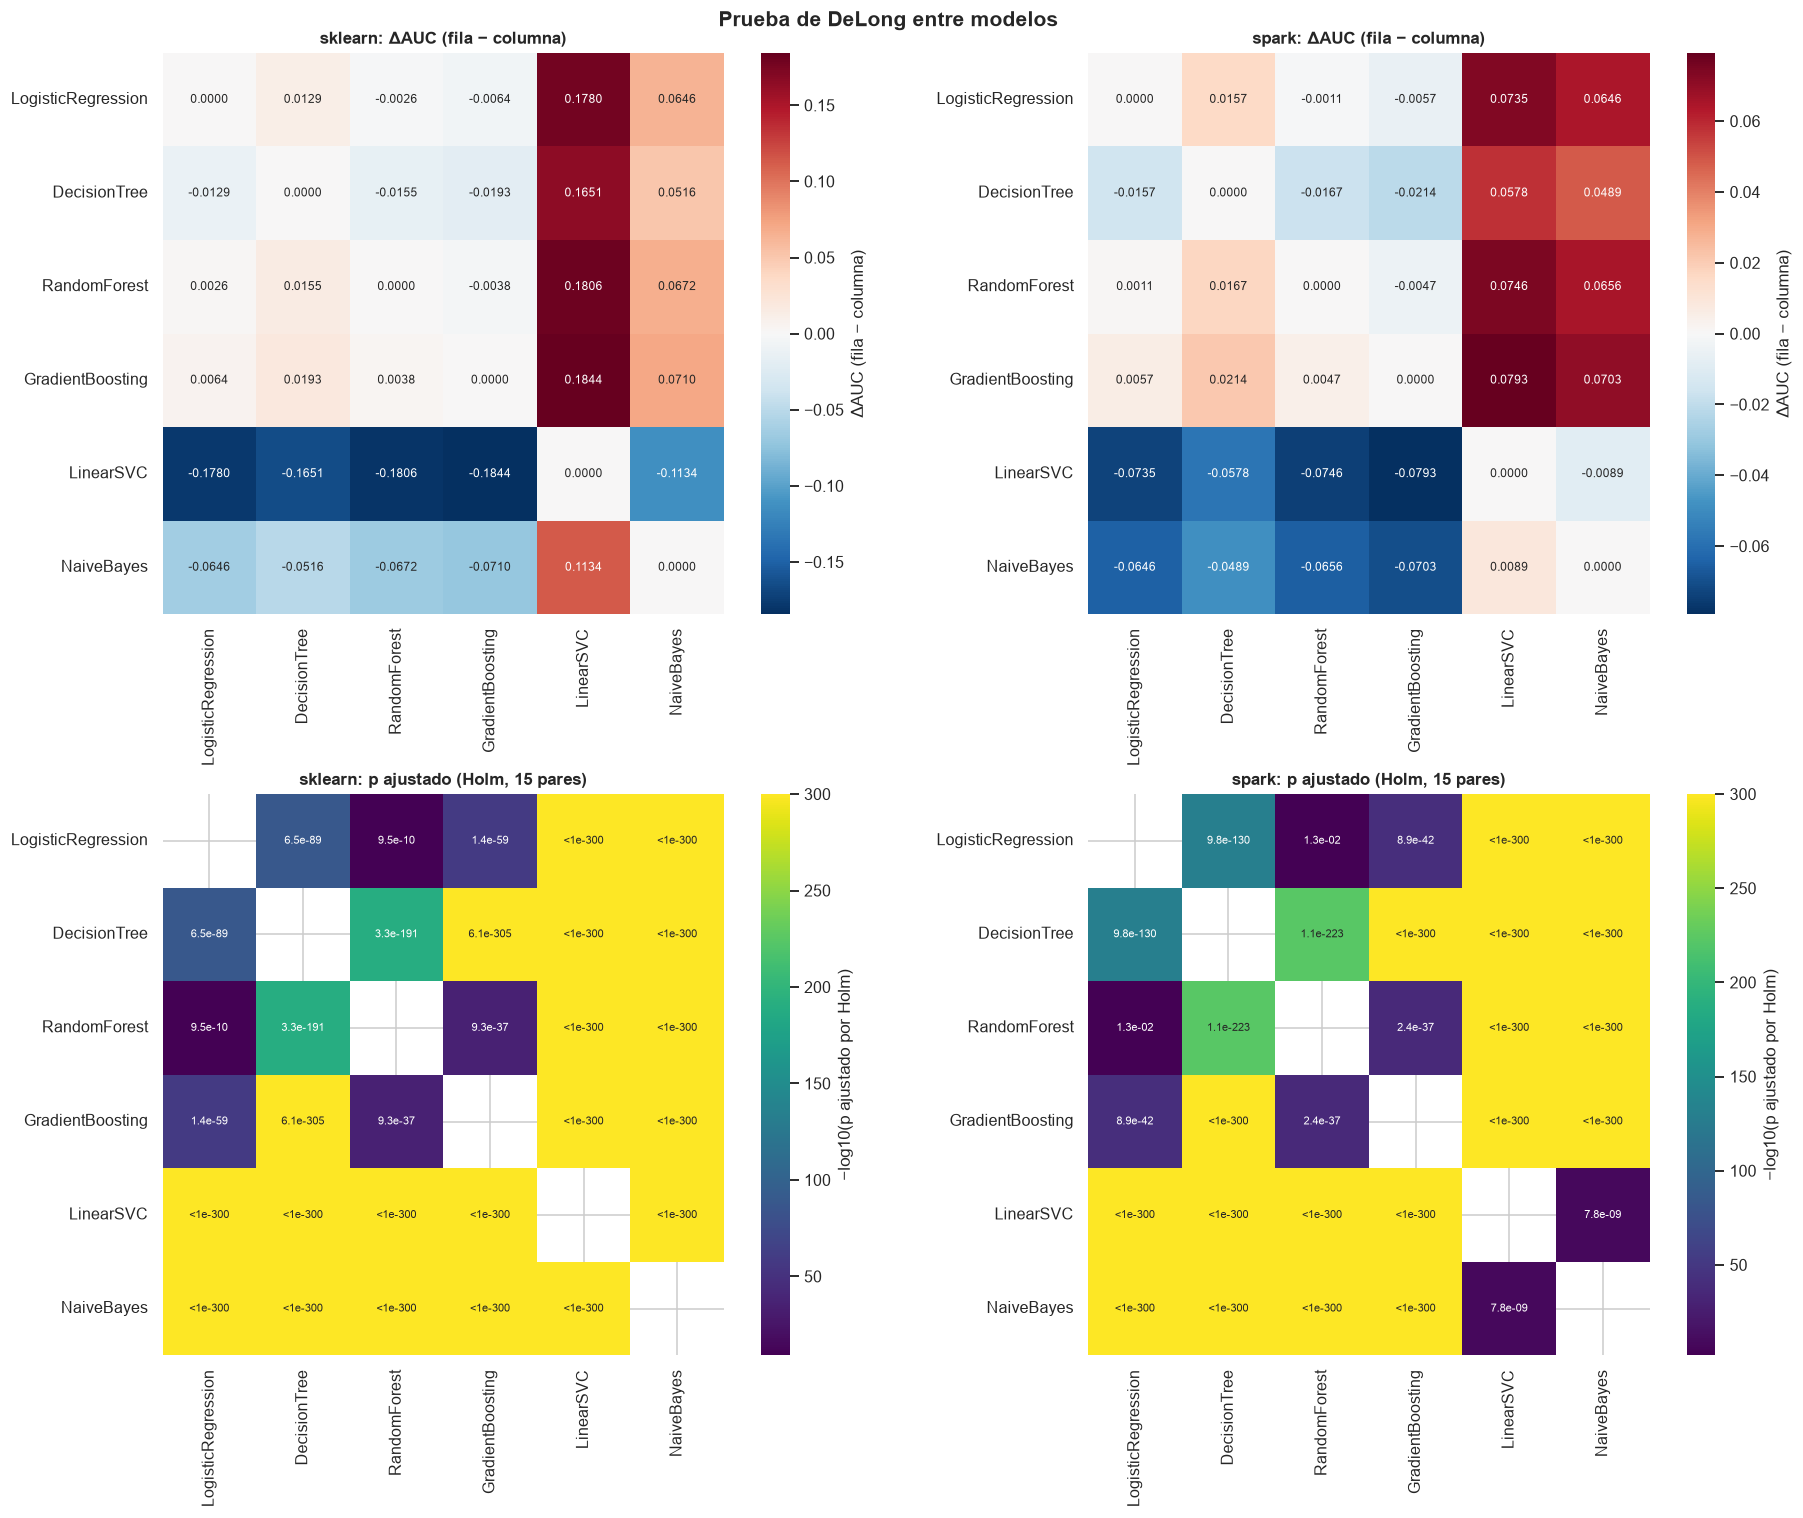

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(17, 14))
for j, e in enumerate(("sklearn", "spark")):
    D = pd.DataFrame(0.0, index=mo.ORDEN, columns=mo.ORDEN)
    P = pd.DataFrame(np.nan, index=mo.ORDEN, columns=mo.ORDEN)
    for _, r in intra[e].iterrows():
        a, b = r["modelo_1"].split(" (")[0], r["modelo_2"].split(" (")[0]
        D.loc[a, b], D.loc[b, a] = r["delta"], -r["delta"]
        P.loc[a, b] = P.loc[b, a] = r["p_holm"]
    lim = np.abs(D.values).max()
    sns.heatmap(D, annot=True, fmt=".4f", cmap="RdBu_r", center=0, vmin=-lim, vmax=lim, square=True,
                ax=axes[0, j], cbar_kws={"label": "ΔAUC (fila − columna)"}, annot_kws={"size": 8})
    axes[0, j].set_title(f"{e}: ΔAUC (fila − columna)")
    anot = P.map(lambda v: "" if np.isnan(v) else ("<1e-300" if v == 0 else f"{v:.1e}"))
    sns.heatmap(-np.log10(P.clip(lower=1e-300)), annot=anot, fmt="", cmap="viridis", square=True,
                ax=axes[1, j], cbar_kws={"label": "−log10(p ajustado por Holm)"}, annot_kws={"size": 7})
    axes[1, j].set_title(f"{e}: p ajustado (Holm, 15 pares)")
fig.suptitle("Prueba de DeLong entre modelos", fontsize=14, weight="bold")
fig.tight_layout()
u.guardar_fig(fig, "08_delong_heatmaps")
plt.show()

Los mapas de calor resumen las 30 comparaciones: en la fila superior, el color indica cuánto
mejor (rojo) o peor (azul) es el modelo de la fila que el de la columna; en la inferior, la
intensidad indica la significancia tras Holm. Los valores anotados de ΔAUC son casi idénticos en
ambos entornos, salvo en la fila y la columna del SVM; los colores no son comparables entre los
dos paneles, porque cada uno usa su propia escala (±0,184 en scikit-learn y ±0,079 en Spark).

## 8.5 McNemar y bootstrap pareado

Alcance: (i) las 6 comparaciones entre entornos y (ii) el par formado por los dos modelos con
mayor AUC dentro de cada entorno. El umbral de cada modelo es el de Youden calculado con
**entrenamiento** (capítulos 6 y 7), nunca con prueba. Holm se aplica dentro de cada familia:
la familia "entre entornos" (6 comparaciones) y la familia "mejores modelos" (2 comparaciones,
una por entorno). Para el bootstrap, el valor p es la proporción de réplicas al otro lado del
cero, duplicada (pasos de 2/B = 0,001), con un mínimo de 1/B = 0,0005 cuando ninguna réplica
cae al otro lado del cero.

In [8]:
def mejores_dos(e):
    t = auc_tab[auc_tab["entorno"] == e].sort_values("auc", ascending=False)
    return list(t["modelo"].iloc[:2])


familias = {
    "entre entornos": [(("sklearn", m), ("spark", m)) for m in mo.ORDEN],
    "mejores modelos": [((e, mejores_dos(e)[0]), (e, mejores_dos(e)[1])) for e in ("sklearn", "spark")],
}
print("Dos mejores por AUC:", {e: mejores_dos(e) for e in ("sklearn", "spark")})

filas = []
for fam, pares in familias.items():
    for a, b in pares:
        dl = est.delong_prueba(y, S[a], S[b])
        pa, pb = (S[a] >= umbral[a]).astype(int), (S[b] >= umbral[b]).astype(int)
        mc = est.mcnemar_prueba(y, pa, pb)
        bs = est.bootstrap_pareado(y, S[a], S[b], umbral[a], umbral[b], B=B, semilla=u.SEMILLA)
        filas.append({"familia": fam, "comparación": f"{a[1]} ({a[0]}) vs {b[1]} ({b[0]})",
                      "ΔAUC": dl["delta"], "p_DeLong": dl["p"],
                      "b (acierta 1, falla 2)": mc["b"], "c (falla 1, acierta 2)": mc["c"],
                      "chi2_McNemar": mc["chi2"], "p_McNemar": mc["p"], "exacta": mc["exacta"],
                      "error_1": mc["error1"], "error_2": mc["error2"],
                      **{f"{k}_{c}": bs.loc[k, c] for k in bs.index
                         for c in ("observada", "media", "ic_inf", "ic_sup", "p_boot")}})
comp = pd.DataFrame(filas)
for fam in familias:
    m = comp["familia"] == fam
    for c in ["p_DeLong", "p_McNemar", "p_boot_AUC", "p_boot_PR", "p_boot_F1"]:
        src = {"p_boot_AUC": "ΔAUC_p_boot", "p_boot_PR": "ΔAUC-PR_p_boot", "p_boot_F1": "ΔF1_p_boot"}.get(c, c)
        comp.loc[m, f"{c}_holm"] = est.holm(comp.loc[m, src])
comp.to_csv(u.RESULTADOS / "comparacion_tres_pruebas.csv", index=False)
comp[["familia", "comparación", "b (acierta 1, falla 2)", "c (falla 1, acierta 2)", "chi2_McNemar",
      "p_McNemar", "p_McNemar_holm", "error_1", "error_2"]].round(5)

Dos mejores por AUC: {'sklearn': ['GradientBoosting', 'RandomForest'], 'spark': ['GradientBoosting', 'RandomForest']}


,familia,comparación,"b (acierta 1, falla 2)","c (falla 1, acierta 2)",chi2_McNemar,p_McNemar,p_McNemar_holm,error_1,error_2
0,entre entornos,LogisticRegression (sklearn) vs LogisticRegres...,1334,336,595.21497,0.00000,0.00000,0.35217,0.35587
1,entre entornos,DecisionTree (sklearn) vs DecisionTree (spark),13611,12997,14.12241,0.00017,0.00034,0.35972,0.36200
2,entre entornos,RandomForest (sklearn) vs RandomForest (spark),6406,5804,29.58239,0.00000,0.00000,0.31445,0.31668
3,entre entornos,GradientBoosting (sklearn) vs GradientBoosting...,6385,6863,17.17459,0.00003,0.00010,0.34710,0.34533
4,entre entornos,LinearSVC (sklearn) vs LinearSVC (spark),46968,83659,10305.34346,0.00000,0.00000,0.48130,0.34521
5,entre entornos,NaiveBayes (sklearn) vs NaiveBayes (spark),0,0,NaN,1.00000,1.00000,0.38013,0.38013
6,mejores modelos,GradientBoosting (sklearn) vs RandomForest (sk...,6897,15701,3429.18882,0.00000,0.00000,0.34710,0.31445
7,mejores modelos,GradientBoosting (spark) vs RandomForest (spark),8572,16296,2398.45299,0.00000,0.00000,0.34533,0.31668


In [9]:
# Umbral de Youden (elegido con entrenamiento) y proporción de préstamos de prueba marcados como default
pd.DataFrame({f"{m} ({e})": {"umbral": umbral[(e, m)], "% marcados como default": 100 * (S[(e, m)] >= umbral[(e, m)]).mean()}
              for e in ("sklearn", "spark") for m in mo.ORDEN}).T.round(4)

,umbral,% marcados como default
LogisticRegression (sklearn),0.1926,42.0274
DecisionTree (sklearn),0.2003,42.3201
RandomForest (sklearn),0.2232,35.6776
GradientBoosting (sklearn),0.1985,41.6973
LinearSVC (sklearn),-1.0000,49.9240
NaiveBayes (sklearn),0.2115,42.8898
LogisticRegression (spark),0.1906,42.6149
DecisionTree (spark),0.1999,42.3631
RandomForest (spark),0.2201,36.0685
GradientBoosting (spark),0.1980,41.3435


McNemar rechaza la igualdad de errores en todas las comparaciones, salvo en Naive Bayes, donde
ambos entornos toman exactamente las mismas decisiones ($b = c = 0$). Dos casos muestran lo que
esta prueba mide y lo que no:

* **Regresión logística entre entornos.** Las puntuaciones son prácticamente idénticas, pero los
  umbrales de Youden difieren en la tercera cifra (0,1926 y 0,1906). Esa pequeña diferencia
  cambia la decisión de 1.670 préstamos cercanos al umbral (1.334 frente a 336), y McNemar la
  declara significativa. La prueba compara decisiones, no modelos: es sensible al umbral.
* **Gradient boosting frente a bosque.** El gradient boosting tiene mejor AUC, pero comete **más**
  errores (34,7 % frente a 31,4 % en scikit-learn y 34,5 % frente a 31,7 % en Spark): su umbral de
  Youden lo lleva a marcar más préstamos como default (tabla anterior), lo que aumenta los
  aciertos en la clase minoritaria y los errores en la mayoritaria. Como McNemar cuenta todos los errores por igual y el 80 % de los préstamos son
  pagados, favorece al modelo que predice menos defaults.

In [10]:
bt = comp[["familia", "comparación"]].copy()
for k, et in (("ΔAUC", "AUC"), ("ΔAUC-PR", "PR"), ("ΔF1", "F1")):
    bt[f"{k} media"] = comp[f"{k}_media"]
    bt[f"{k} IC95"] = comp.apply(lambda r: f"[{r[f'{k}_ic_inf']:+.4f}, {r[f'{k}_ic_sup']:+.4f}]", axis=1)
    bt[f"{k} p_holm"] = comp[f"p_boot_{et}_holm"]
bt.round(4)

,familia,comparación,ΔAUC media,ΔAUC IC95,ΔAUC p_holm,ΔAUC-PR media,ΔAUC-PR IC95,ΔAUC-PR p_holm,ΔF1 media,ΔF1 IC95,ΔF1 p_holm
0,entre entornos,LogisticRegression (sklearn) vs LogisticRegres...,-0.0000,"[-0.0000, +0.0000]",0.972,-0.0001,"[-0.0001, -0.0000]",0.003,0.0006,"[+0.0002, +0.0010]",0.003
1,entre entornos,DecisionTree (sklearn) vs DecisionTree (spark),0.0027,"[+0.0018, +0.0037]",0.003,0.0037,"[+0.0017, +0.0057]",0.003,0.0032,"[+0.0017, +0.0047]",0.003
2,entre entornos,RandomForest (sklearn) vs RandomForest (spark),0.0015,"[+0.0011, +0.0019]",0.003,0.0022,"[+0.0014, +0.0030]",0.003,0.0000,"[-0.0012, +0.0012]",1.000
3,entre entornos,GradientBoosting (sklearn) vs GradientBoosting...,0.0007,"[+0.0002, +0.0011]",0.006,0.0018,"[+0.0008, +0.0027]",0.003,0.0004,"[-0.0007, +0.0015]",1.000
4,entre entornos,LinearSVC (sklearn) vs LinearSVC (spark),-0.1045,"[-0.1084, -0.1008]",0.003,-0.1026,"[-0.1064, -0.0989]",0.003,-0.0770,"[-0.0804, -0.0735]",0.003
5,entre entornos,NaiveBayes (sklearn) vs NaiveBayes (spark),0.0000,"[-0.0000, +0.0000]",0.972,0.0000,"[-0.0000, +0.0001]",0.598,0.0000,"[+0.0000, +0.0000]",1.000
6,mejores modelos,GradientBoosting (sklearn) vs RandomForest (sk...,0.0038,"[+0.0032, +0.0044]",0.001,0.0067,"[+0.0055, +0.0079]",0.001,0.0022,"[+0.0007, +0.0038]",0.018
7,mejores modelos,GradientBoosting (spark) vs RandomForest (spark),0.0047,"[+0.0040, +0.0054]",0.001,0.0071,"[+0.0056, +0.0086]",0.001,0.0018,"[+0.0003, +0.0034]",0.023


El bootstrap pareado confirma las diferencias de AUC detectadas por DeLong y añade las métricas
centradas en la clase minoritaria:

* Entre entornos, el árbol, el bosque y el gradient boosting de scikit-learn tienen un AUC-PR
  algo mayor (0,0018 a 0,0037), coherente con su AUC; en F1, en cambio, las diferencias del
  bosque y del gradient boosting no son significativas (sus intervalos contienen el cero).
* Entre los dos mejores modelos, el gradient boosting supera al bosque en AUC-PR en 0,0067
  (scikit-learn) y 0,0071 (Spark), por encima del margen de 0,005, aunque en AUC la diferencia
  entre ambos no lo alcanza. Su ventaja en F1 es pequeña (0,002) pero significativa.

### Coherencia entre DeLong y el bootstrap para el AUC

Para el AUC ambas pruebas estiman la misma cantidad; el IC del bootstrap y el de DeLong deben ser
casi iguales. Para que la comparación sea limpia se confrontan los dos criterios sin ajustar
(p de DeLong < 0,05 frente a IC del 95 % que excluye el cero); la corrección de Holm se aplica en
la tabla resumen de la sección 8.6.

In [11]:
coh = pd.DataFrame({"comparación": comp["comparación"], "ΔAUC": comp["ΔAUC"],
                    "IC DeLong": [f"[{r['delta_inf']:+.4f}, {r['delta_sup']:+.4f}]" for _, r in pd.DataFrame(
                        [est.delong_prueba(y, S[a], S[b]) for pares in familias.values() for a, b in pares]).iterrows()],
                    "IC bootstrap": comp.apply(lambda r: f"[{r['ΔAUC_ic_inf']:+.4f}, {r['ΔAUC_ic_sup']:+.4f}]", axis=1),
                    "DeLong p < 0,05 (sin ajustar)": comp["p_DeLong"] < ALFA,
                    "bootstrap excluye 0": (comp["ΔAUC_ic_inf"] > 0) | (comp["ΔAUC_ic_sup"] < 0)})
coh["coinciden"] = coh["DeLong p < 0,05 (sin ajustar)"] == coh["bootstrap excluye 0"]
coh

,comparación,ΔAUC,IC DeLong,IC bootstrap,"DeLong p < 0,05 (sin ajustar)",bootstrap excluye 0,coinciden
0,LogisticRegression (sklearn) vs LogisticRegres...,-8.167076e-06,"[-0.0000, +0.0000]","[-0.0000, +0.0000]",False,False,True
1,DecisionTree (sklearn) vs DecisionTree (spark),2.736836e-03,"[+0.0017, +0.0037]","[+0.0018, +0.0037]",True,True,True
2,RandomForest (sklearn) vs RandomForest (spark),1.527922e-03,"[+0.0011, +0.0020]","[+0.0011, +0.0019]",True,True,True
3,GradientBoosting (sklearn) vs GradientBoosting...,6.569554e-04,"[+0.0002, +0.0011]","[+0.0002, +0.0011]",True,True,True
4,LinearSVC (sklearn) vs LinearSVC (spark),-1.044917e-01,"[-0.1083, -0.1007]","[-0.1084, -0.1008]",True,True,True
5,NaiveBayes (sklearn) vs NaiveBayes (spark),6.539856e-09,"[-0.0000, +0.0000]","[-0.0000, +0.0000]",False,False,True
6,GradientBoosting (sklearn) vs RandomForest (sk...,3.812602e-03,"[+0.0032, +0.0044]","[+0.0032, +0.0044]",True,True,True
7,GradientBoosting (spark) vs RandomForest (spark),4.683569e-03,"[+0.0040, +0.0054]","[+0.0040, +0.0054]",True,True,True


DeLong y el bootstrap coinciden en las ocho comparaciones: los intervalos del 95 % difieren a lo
sumo en una unidad de la cuarta cifra decimal y llevan a la misma conclusión. Es lo esperado,
porque con este tamaño de muestra la aproximación normal de DeLong es excelente.

## 8.6 Resumen de las tres pruebas

In [12]:
def veredicto(p, d=None):
    s = "sí" if p < ALFA else "no"
    if d is not None and p < ALFA:
        s += " (relevante)" if abs(d) >= MARGEN else " (no relevante)"
    return s


res = pd.DataFrame({
    "familia": comp["familia"], "comparación": comp["comparación"],
    "ΔAUC": comp["ΔAUC"].round(4),
    "DeLong": [veredicto(p, d) for p, d in zip(comp["p_DeLong_holm"], comp["ΔAUC"])],
    "McNemar": [veredicto(p) for p in comp["p_McNemar_holm"]],
    "Bootstrap ΔAUC": [veredicto(p, d) for p, d in zip(comp["p_boot_AUC_holm"], comp["ΔAUC_media"])],
    "Bootstrap ΔAUC-PR": [veredicto(p, d) for p, d in zip(comp["p_boot_PR_holm"], comp["ΔAUC-PR_media"])],
    "Bootstrap ΔF1": [veredicto(p, d) for p, d in zip(comp["p_boot_F1_holm"], comp["ΔF1_media"])],
})
res.to_csv(u.RESULTADOS / "resumen_tres_pruebas.csv", index=False)
res

,familia,comparación,ΔAUC,DeLong,McNemar,Bootstrap ΔAUC,Bootstrap ΔAUC-PR,Bootstrap ΔF1
0,entre entornos,LogisticRegression (sklearn) vs LogisticRegres...,-0.0000,no,sí,no,sí (no relevante),sí (no relevante)
1,entre entornos,DecisionTree (sklearn) vs DecisionTree (spark),0.0027,sí (no relevante),sí,sí (no relevante),sí (no relevante),sí (no relevante)
2,entre entornos,RandomForest (sklearn) vs RandomForest (spark),0.0015,sí (no relevante),sí,sí (no relevante),sí (no relevante),no
3,entre entornos,GradientBoosting (sklearn) vs GradientBoosting...,0.0007,sí (no relevante),sí,sí (no relevante),sí (no relevante),no
4,entre entornos,LinearSVC (sklearn) vs LinearSVC (spark),-0.1045,sí (relevante),sí,sí (relevante),sí (relevante),sí (relevante)
5,entre entornos,NaiveBayes (sklearn) vs NaiveBayes (spark),0.0000,no,no,no,no,no
6,mejores modelos,GradientBoosting (sklearn) vs RandomForest (sk...,0.0038,sí (no relevante),sí,sí (no relevante),sí (relevante),sí (no relevante)
7,mejores modelos,GradientBoosting (spark) vs RandomForest (spark),0.0047,sí (no relevante),sí,sí (no relevante),sí (relevante),sí (no relevante)


**Coincidencias y discrepancias entre las tres pruebas.**

* DeLong y el bootstrap del AUC coinciden siempre, como debe ser: estiman la misma cantidad.
* McNemar y DeLong discrepan en dos sentidos. En la regresión logística entre entornos, McNemar
  detecta una diferencia que DeLong no ve, porque compara decisiones con umbrales ligeramente
  distintos y no la capacidad de ordenar. En gradient boosting frente a bosque, ambas son
  significativas pero apuntan en direcciones opuestas: DeLong favorece al gradient boosting
  (mejor ordenamiento) y McNemar al bosque (menos errores en su umbral). Lo mismo ocurre con el
  gradient boosting entre entornos: DeLong favorece a scikit-learn (ΔAUC = 0,0007) y McNemar a
  Spark (34,5 % de errores frente a 34,7 %).
* El bootstrap de AUC-PR y F1 matiza las diferencias entre entornos: con F1 en el umbral de
  Youden, el bosque y el gradient boosting de ambos entornos son indistinguibles.

La conclusión común es que, salvo el SVM, ningún modelo cambia de manera relevante al pasar de
scikit-learn a PySpark. Dentro de cada entorno, DeLong y el bootstrap señalan al gradient boosting
como el mejor en capacidad de ordenamiento (ventaja sobre el bosque de 0,0038 y 0,0047 en AUC,
significativa pero por debajo del margen; de 0,007 en AUC-PR, por encima), mientras que McNemar,
en los umbrales elegidos, favorece al bosque.

In [13]:
entre.to_csv(u.RESULTADOS / "delong_entre_entornos.csv", index=False)
pd.concat(intra.values()).to_csv(u.RESULTADOS / "delong_entre_modelos.csv", index=False)
auc_tab.to_csv(u.RESULTADOS / "auc_ic_delong.csv", index=False)